In [ ]:
import numpy as np 
import pandas as pd 

import glob
import os.path as path
import imageio

from skimage import color
from skimage import io

import random

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

### Data preprocessing

In [ ]:
# 파일 경로 지정
IMAGE_PATH_female = 'female'
file_paths_female = glob.glob(path.join(IMAGE_PATH_female, '*.jpg'))

IMAGE_PATH_male = 'male'
file_paths_male = glob.glob(path.join(IMAGE_PATH_male, '*.jpg'))

file_paths = file_paths_female + file_paths_male

In [ ]:
print('female:',len(file_paths_female))
print('male:',len(file_paths_male))

female: 1947
male: 1944


In [ ]:
# 이미지 사이즈가 각기 달라서 crop 함수 이용해 사이즈 통일
from PIL import Image

for path in file_paths:
    image = Image.open(path)
    # 이미지 자르기 crop함수 이용 -> crop(left, up, rigth, down)
    image = image.crop(((image.size[0]/2)-32,(image.size[1]/2)-45,(image.size[0]/2)+32,(image.size[1]/2)+45))
    image.save(path)

In [ ]:
# 이미지 불러오기
images = [imageio.imread(path) for path in file_paths]

In [ ]:
# 이미지 데이터를 numpy로 변환
images = np.asarray(images)

# 총 3891개의 이미지, 90x64픽셀, 마지막에 3은 RGB라는 3개의 체널이 있음을 의미한다.
images.shape

(3891, 90, 64, 3)

In [ ]:
# 각 이미지에 라벨을 붙여야 하는데,
# 파일 이름 맨 앞부분을 활용하여 라벨을 부여한다.
file_paths[:5]

['female/0071.jpg',
 'female/0717.jpg',
 'female/1409.jpg',
 'female/0703.jpg',
 'female/0065.jpg']

In [ ]:
# 0, 1 라벨 붙이기
n_images = images.shape[0]
labels = np.zeros(n_images)
for i in range(n_images):
    if file_paths[i][0] == 'f':
        labels[i] = 1
    else:
        labels[i] = 0
print(labels)

# 원핫인코딩
one_hot_labels = np.zeros([n_images,2]) 
for i in range(n_images):
    one_hot_labels[i, int(labels[i])] = 1.
print(one_hot_labels)

[1. 1. 1. ... 0. 0. 0.]
[[0. 1.]
 [0. 1.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


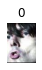

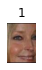

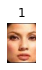

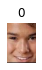

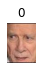

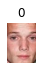

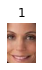

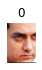

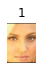

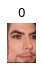

In [ ]:
# 시각화
count = 0
num = [random.randint(0,images.shape[0]) for i in range(10)]
for i in num: # 임의로 10개의 이미지를 가져와서 사진으로 보여주기
    count += 1
    figure = plt.figure()
    figure.add_subplot(2, 10, count)
    plt.imshow(images[i, :])
    plt.axis('off')
    plt.title(int(labels[i]))

In [ ]:
# 컬러이미지는 3차원인데 이를 1차원으로 reshape하고 255로 나누어 정규화한다.
images = images.reshape(-1, 90*64*3) / 255
images.shape

(3891, 17280)

In [ ]:
# train data와 test data로 나누기
x_train, x_test, y_train, y_test = train_test_split(images, one_hot_labels, test_size=0.05)

print('total',images.shape, one_hot_labels.shape)
print('train set',x_train.shape, y_train.shape)
print('test set', x_test.shape, y_test.shape)

total (3891, 17280) (3891, 2)
train set (3696, 17280) (3696, 2)
test set (195, 17280) (195, 2)


### MLP - Backpropagation

In [ ]:
def sigmoid(x):
        return 1.0/(1.0 + np.exp(-x))

def init_network(input_dim, hidden_dim, output_dim):
    W = np.random.randn(input_dim, hidden_dim)
    b = np.random.randn(hidden_dim)
    V = np.random.randn(hidden_dim, output_dim )
    c = np.random.randn(output_dim)
    return W, b, V, c
    
def forward(x, W, b, V, c):
    z = sigmoid(np.matmul(x, W) - b)
    y = sigmoid(np.matmul(z, V) - c)
    return z, y

def backward(x, true_y, W, b, V, c, lr=0.01):
    z, y = forward(x, W, b, V, c)
    error_y = (true_y - y)*y*(1-y)
    error_z = error_y.dot(V.T)*z*(1-z)   
    
    V = V + lr * np.matmul(z.T, error_y)
    W = W + lr * np.matmul(x.T, error_z)
    c = c + lr * np.sum(error_y,axis=0)*(-1.)
    b = b + lr * np.sum(error_z,axis=0)*(-1.)
    return W, b, V, c 

epoch: 0/200, error: 194/200
epoch: 20/200, error: 152/200
epoch: 40/200, error: 142/200
epoch: 60/200, error: 131/200
epoch: 80/200, error: 158/200
epoch: 100/200, error: 108/200
epoch: 120/200, error: 144/200
epoch: 140/200, error: 102/200
epoch: 160/200, error: 118/200
epoch: 180/200, error: 144/200


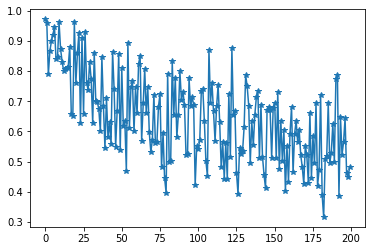

In [ ]:
batch_size = 200
epoch_num = 200

W, b, V, c = init_network(input_dim=17280, hidden_dim=100, output_dim=2)
epoch_dat = []
error_dat = []

for epoch in range(epoch_num):
    for a in range(int(images.shape[0]/batch_size)):
        
        num = [random.randint(0,3000) for i in range(batch_size)] # batch_size 만큼의 이미지를 임의로 뽑는다.
        x = x_train[num, :] 
        x = x.reshape(x.shape[0],17280)
        true_y = y_train[num] 

        W, b, V, c = backward(x, true_y, W, b, V, c, lr=0.02)
        z, y = forward(x, W, b, V, c)
        train_error = np.sum(np.abs(true_y - y))
    
    epoch_dat.append(epoch)
    error_dat.append(train_error/batch_size) 
    
    if epoch % 20 == 0: 
        print( 'epoch: %d/%d, error: %d/%d'%(epoch, epoch_num, train_error, batch_size))

plt.plot(epoch_dat, error_dat, '-*')
plt.show()

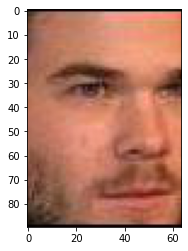

true_label = 0, predicted_label =0


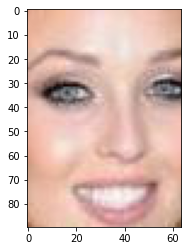

true_label = 1, predicted_label =1


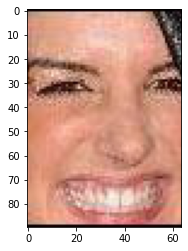

true_label = 1, predicted_label =1


In [ ]:
# prediction
for i in range(3):
    index = random.randint(0,x_test.shape[0]) # 아무 이미지나 뽑기
    img = x_test[index,:]
    true_label = y_test[index]

    plt.imshow(img.reshape(90,64,3))
    plt.show()

    x = img.reshape(17280)
    z, y = forward(x, W, b, V, c) 
    print('true_label = %s, predicted_label =%d' %(np.where(y_test[index] == 1)[0][0], np.argmax(y))) 